<a href="https://colab.research.google.com/github/RogerVin1/PA2_Deep_Learning/blob/main/Assignment2_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 0:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
def mascara_elipse(H, W, cx, cy, a, b, theta):
    """Devolve uma matriz booleana [H,W]: True nos pixels dentro da elipse."""
    ys, xs = np.mgrid[0:H, 0:W]
    dx, dy = xs - cx, ys - cy
    ct, st = np.cos(theta), np.sin(theta)
    xr = dx * ct + dy * st        # gira o sistema de coordenadas
    yr = -dx * st + dy * ct
    return (xr / max(a, 1e-6)) ** 2 + (yr / max(b, 1e-6)) ** 2 <= 1.0

In [3]:
def caixa_da_elipse(cx, cy, a, b, theta):
    """Caixa (x_esq, y_topo, largura, altura) que envolve a elipse."""
    ct, st = np.cos(theta), np.sin(theta)
    hw = np.sqrt((a * ct) ** 2 + (b * st) ** 2)   # meia-largura
    hh = np.sqrt((a * st) ** 2 + (b * ct) ** 2)   # meia-altura
    return cx - hw, cy - hh, 2 * hw, 2 * hh

In [4]:
def gerar_video(n_objs=8, T=45, H=128, W=128, vel_tipica=2.5,
                dur_oclusao=12, ruido=0.05, contraste=1.0, seed=0):
    rng = np.random.default_rng(seed)
    objs = []

    # objeto ALVO (id=1): atravessa a cena na horizontal; é quem "some e volta"
    alvo_y, alvo_a, alvo_b = H / 2, 7.0, 5.0
    x0 = W / 2 - vel_tipica * (T // 2)      # comeca a esquerda, chega ao centro no meio do video
    objs.append(dict(id=1, x=x0, y=alvo_y, vx=vel_tipica, vy=0.0,
                     a=alvo_a, b=alvo_b, theta=0.0,
                     z=0.0, inten=0.95, scripted=True))   # z BAIXO = distante

    # objeto OCLUSOR (id=2): grande, parado no centro, NA FRENTE (z alto).
    # largura calculada para prender o alvo atras por ~dur_oclusao quadros
    a_occ = max(8.0, vel_tipica * dur_oclusao / 2 + alvo_a)
    objs.append(dict(id=2, x=W / 2, y=alvo_y, vx=0.0, vy=0.0,
                     a=a_occ, b=alvo_b * 3, theta=0.0,
                     z=10.0, inten=0.45, scripted=True))   # z ALTO = na frente

    # demais objetos: livres, quicando nas bordas, tamanhos/velocidades variados
    for k in range(max(0, n_objs - 2)):
        a, b = rng.uniform(4, 9), rng.uniform(4, 9)
        objs.append(dict(id=3 + k,
            x=rng.uniform(a, W - a), y=rng.uniform(b, H - b),
            vx=rng.uniform(-1, 1) * vel_tipica, vy=rng.uniform(-1, 1) * vel_tipica,
            a=a, b=b, theta=rng.uniform(0, np.pi),
            z=rng.uniform(1, 9), inten=rng.uniform(0.6, 1.0), scripted=False))

    frames = np.zeros((T, H, W), np.float32)
    gt = []
    bg = 0.15                                    # cinza de fundo

    for t in range(T):
        # (1) mascara de cada objeto na posicao atual
        masks = [mascara_elipse(H, W, o['x'], o['y'], o['a'], o['b'], o['theta'])
                 for o in objs]

        # (2) RENDER: pinta do mais distante ao mais proximo (algoritmo do pintor)
        canvas = np.full((H, W), bg, np.float32)
        for i in sorted(range(len(objs)), key=lambda i: objs[i]['z']):
            canvas[masks[i]] = objs[i]['inten']
        img = 0.5 + contraste * (canvas - 0.5)   # contraste em torno de 0.5
        frames[t] = np.clip(img + rng.normal(0, ruido, img.shape), 0, 1)

        # (3) VISIBILIDADE: do mais proximo ao mais distante, marcando pixels ocupados
        ocupado = np.zeros((H, W), bool)
        vis = [0.0] * len(objs)
        for i in sorted(range(len(objs)), key=lambda i: -objs[i]['z']):
            area = masks[i].sum()
            vis[i] = float(np.logical_and(masks[i], ~ocupado).sum()) / area if area > 0 else 0.0
            ocupado |= masks[i]

        # (4) grava o gabarito deste quadro (caixa verdadeira MESMO sob oclusao)
        for i, o in enumerate(objs):
            x, y, w, h = caixa_da_elipse(o['x'], o['y'], o['a'], o['b'], o['theta'])
            gt.append(dict(frame=t, id=o['id'], x=x, y=y, w=w, h=h, vis=vis[i]))

        # (5) move os objetos (os livres quicam nas bordas)
        for o in objs:
            o['x'] += o['vx']; o['y'] += o['vy']
            if not o['scripted']:
                if o['x'] < o['a'] or o['x'] > W - o['a']:
                    o['vx'] *= -1; o['x'] = np.clip(o['x'], o['a'], W - o['a'])
                if o['y'] < o['b'] or o['y'] > H - o['b']:
                    o['vy'] *= -1; o['y'] = np.clip(o['y'], o['b'], H - o['b'])

    return frames, gt

Alvo some no quadro 16 e volta no 29 (13 quadros ocluido)


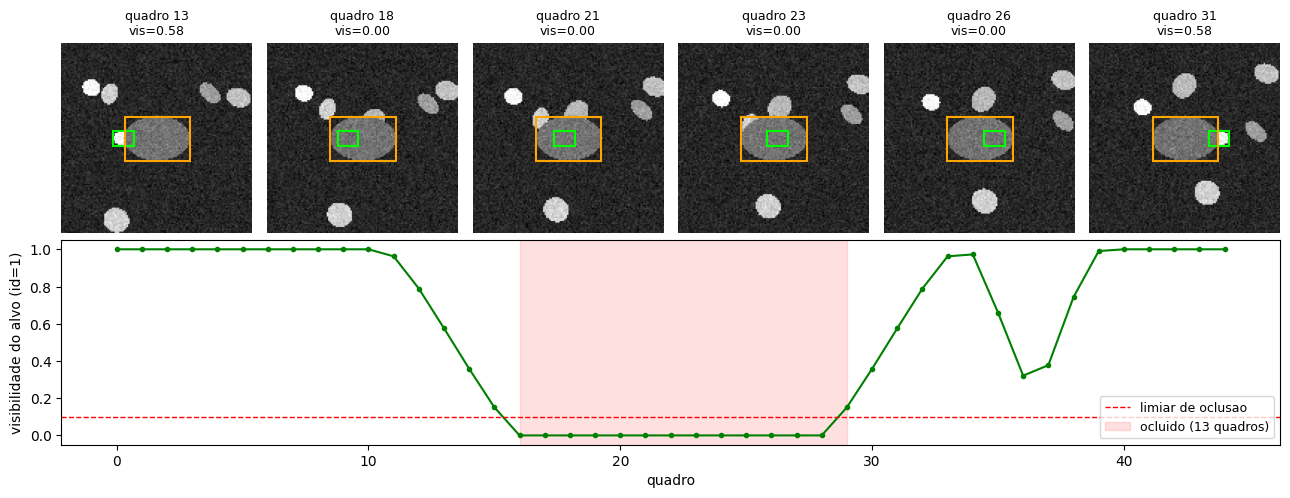

In [5]:
frames, gt = gerar_video(n_objs=8, T=45, vel_tipica=2.5, dur_oclusao=12, seed=0)
T = frames.shape[0]

vis_alvo = np.array([r['vis'] for r in gt if r['id'] == 1])
faixa = np.where(vis_alvo < 0.1)[0]
if len(faixa):
    print(f"Alvo some no quadro {faixa[0]} e volta no {faixa[-1]+1} "
          f"({len(faixa)} quadros ocluido)")
    c = (faixa[0] + faixa[-1]) // 2
else:
    c = T // 2
sel = sorted(set(np.clip([c-9, c-4, c-1, c+1, c+4, c+9], 0, T-1)))

fig = plt.figure(figsize=(13, 5))
for j, t in enumerate(sel):                          # painel de cima: tira de quadros
    ax = fig.add_subplot(2, len(sel), j + 1)
    ax.imshow(frames[t], cmap="gray", vmin=0, vmax=1)
    for r in [x for x in gt if x['frame'] == t and x['id'] in (1, 2)]:
        cor = "lime" if r['id'] == 1 else "orange"
        ax.add_patch(patches.Rectangle((r['x'], r['y']), r['w'], r['h'],
                     fill=False, edgecolor=cor, linewidth=1.5))
    v = [x['vis'] for x in gt if x['frame'] == t and x['id'] == 1][0]
    ax.set_title(f"quadro {t}\nvis={v:.2f}", fontsize=9); ax.axis("off")

ax = fig.add_subplot(2, 1, 2)                         # painel de baixo: visibilidade
ax.plot(range(T), vis_alvo, color="green", marker="o", ms=3)
ax.axhline(0.1, color="red", ls="--", lw=1, label="limiar de oclusao")
if len(faixa):
    ax.axvspan(faixa[0], faixa[-1] + 1, color="red", alpha=0.12,
               label=f"ocluido ({len(faixa)} quadros)")
ax.set_xlabel("quadro"); ax.set_ylabel("visibilidade do alvo (id=1)")
ax.set_ylim(-0.05, 1.05); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

In [6]:
def simular_detector(gt, H=128, W=128, p_descarte=0.1, ruido_caixa=2.0,
                     taxa_falsos=1.0, seed=0):
    """
    p_descarte  : fracao das caixas verdadeiras que somem (falso negativo)
    ruido_caixa : desvio-padrao (pixels) do ruido somado a x,y,w,h
    taxa_falsos : numero MEDIO de falsos positivos por quadro
    Devolve: dets = lista de dicts {frame, x, y, w, h, conf}   (repare: SEM id!)
    """
    rng = np.random.default_rng(seed)
    T = max(r['frame'] for r in gt) + 1
    dets = []
    for t in range(T):
        for r in [g for g in gt if g['frame'] == t]:
            if rng.random() > r['vis']:      # muito ocluido -> some para o detector
                continue
            if rng.random() < p_descarte:    # falha aleatoria (falso negativo)
                continue
            dets.append(dict(frame=t,        # detectado, mas com ruido nas coordenadas
                x=r['x'] + rng.normal(0, ruido_caixa),
                y=r['y'] + rng.normal(0, ruido_caixa),
                w=max(2.0, r['w'] + rng.normal(0, ruido_caixa)),
                h=max(2.0, r['h'] + rng.normal(0, ruido_caixa)),
                conf=rng.uniform(0.6, 1.0)))
        for _ in range(rng.poisson(taxa_falsos)):   # falsos positivos (caixas do nada)
            w, h = rng.uniform(6, 18), rng.uniform(6, 18)
            dets.append(dict(frame=t, x=rng.uniform(0, W - w), y=rng.uniform(0, H - h),
                             w=w, h=h, conf=rng.uniform(0.1, 0.7)))
    return dets

gt: 360 | deteccoes: 316 | tem id? False


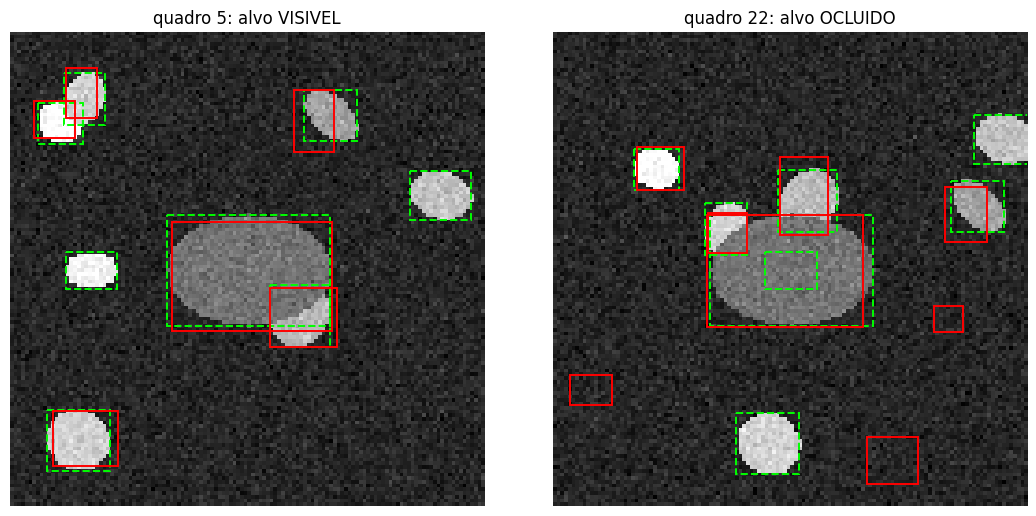

In [7]:
dets = simular_detector(gt, p_descarte=0.1, ruido_caixa=2.0, taxa_falsos=1.0, seed=1)
print("gt:", len(gt), "| deteccoes:", len(dets), "| tem id?", 'id' in dets[0])

faixa = [r['frame'] for r in gt if r['id'] == 1 and r['vis'] < 0.1]
t_ocl, t_viz = faixa[len(faixa)//2], 5

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, t, titulo in [(axes[0], t_viz, f"quadro {t_viz}: alvo VISIVEL"),
                      (axes[1], t_ocl, f"quadro {t_ocl}: alvo OCLUIDO")]:
    ax.imshow(frames[t], cmap="gray", vmin=0, vmax=1)
    for r in [g for g in gt if g['frame'] == t]:      # gabarito: verde tracejado
        ax.add_patch(patches.Rectangle((r['x'], r['y']), r['w'], r['h'], fill=False,
                     edgecolor="lime", lw=1.4, linestyle="--"))
    for d in [x for x in dets if x['frame'] == t]:    # deteccoes: vermelho solido
        ax.add_patch(patches.Rectangle((d['x'], d['y']), d['w'], d['h'], fill=False,
                     edgecolor="red", lw=1.4))
    ax.set_title(titulo); ax.axis("off")
plt.tight_layout(); plt.show()